# **Support Vectore Classifier Implementation**

In [2]:
from ast import increment_lineno
#Import Basic liberies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#Lets create a synthetic data point
from sklearn.datasets import  make_classification
x,y=make_classification(n_samples=1000,n_features=5,n_classes=2,random_state=10,n_clusters_per_class=1)


In [4]:
x

array([[-0.82402824, -1.01365407,  0.61849983,  1.03678565, -1.10652807],
       [-2.21125387,  1.32788405, -0.77700022,  0.00619763,  1.20452564],
       [-0.61030611,  0.06711293, -0.03423578, -0.45967388,  0.02375715],
       ...,
       [ 0.74093104, -2.02631043,  1.21227285,  0.88811468, -2.03414671],
       [-1.32053664,  0.13251191, -0.06643069, -0.02168073,  0.03830683],
       [-1.48868787, -0.08849854,  0.06830665, -0.79967344, -0.20209591]])

<Axes: xlabel='0', ylabel='1'>

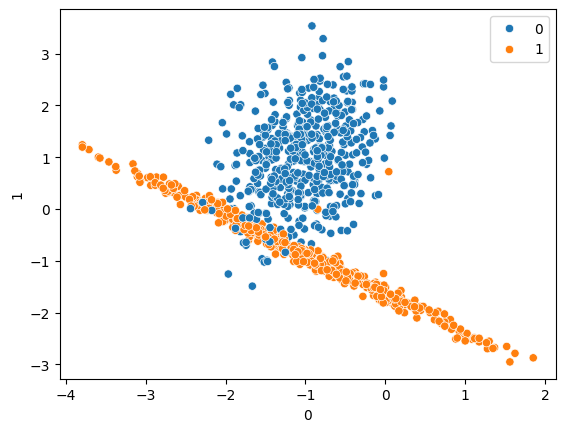

In [5]:
sns.scatterplot(x=pd.DataFrame(x)[0], y=pd.DataFrame(x)[1], hue=y)

In [6]:
#train split the dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [8]:
#Model Traning
from sklearn.svm import SVC
model=SVC(kernel='linear')
model.fit(x_train,y_train)

SVC(kernel='linear')

In [9]:
#Predic the result
y_pred=model.predict(x_test)

In [11]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.96
[[ 92   7]
 [  1 100]]
              precision    recall  f1-score   support

           0       0.99      0.93      0.96        99
           1       0.93      0.99      0.96       101

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [12]:
#Model Traning
from sklearn.svm import SVC
model_rbf=SVC(kernel='rbf')
model_rbf.fit(x_train,y_train)

SVC()

In [13]:
#prin the accuracy,confusion_metrics,classification_report
y_pred_rbf=model_rbf.predict(x_test)
print(accuracy_score(y_test,y_pred_rbf))
print(confusion_matrix(y_test,y_pred_rbf))
print(classification_report(y_test,y_pred_rbf))

0.95
[[ 90   9]
 [  1 100]]
              precision    recall  f1-score   support

           0       0.99      0.91      0.95        99
           1       0.92      0.99      0.95       101

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [14]:
from sklearn.svm import SVC
model_polynomial=SVC(kernel='poly')
model_polynomial.fit(x_train,y_train)

SVC(kernel='poly')

In [16]:
#Model Training with Sigmoid Kernel
from sklearn.svm import SVC
model_sigmoid=SVC(kernel='sigmoid')
model_sigmoid.fit(x_train,y_train)

SVC(kernel='sigmoid')

In [17]:
#Predict the result and print metrics for Sigmoid Kernel
y_pred_sigmoid=model_sigmoid.predict(x_test)
print(accuracy_score(y_test,y_pred_sigmoid))
print(confusion_matrix(y_test,y_pred_sigmoid))
print(classification_report(y_test,y_pred_sigmoid))

0.815
[[83 16]
 [21 80]]
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        99
           1       0.83      0.79      0.81       101

    accuracy                           0.81       200
   macro avg       0.82      0.82      0.81       200
weighted avg       0.82      0.81      0.81       200



In [15]:
y_pred_poly=model_polynomial.predict(x_test)
print(accuracy_score(y_test,y_pred_poly))
print(confusion_matrix(y_test,y_pred_poly))

0.965
[[ 93   6]
 [  1 100]]


# **By using GridSearchCV**
Hyperparameter Tuning

In [20]:
from sklearn.model_selection import GridSearchCV
param_grid={'C':[0.1,1,10,50,100,1000],'gamma':[1,0.5,0.1,0.01,0.001,0.0001],'kernel':['rbf']}

In [21]:
grid=GridSearchCV(SVC(),param_grid,refit=True,verbose=3)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.956 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.944 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.963 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.938 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.956 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.956 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.950 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.950 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.925 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.5, kernel=rbf;, score=0.950 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.956 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50, 100, 1000],
                         'gamma': [1, 0.5, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [22]:
grid.best_params_

{'C': 1000, 'gamma': 0.1, 'kernel': 'rbf'}

In [23]:
grid.best_score_

np.float64(0.9675)

In [24]:
#prediction and print result
y_pred_grid=grid.predict(x_test)
print(accuracy_score(y_test,y_pred_grid))
print(confusion_matrix(y_test,y_pred_grid))

0.975
[[96  3]
 [ 2 99]]
